In [1]:
import pandas as pd

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv")
#train_data = train_data.drop('id', axis = 1)

In [3]:
train_data.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [4]:
train_data['Compound'].unique()

array(['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET'], dtype=object)

In [5]:
train_data['Compound'] = train_data['Compound'].str.upper().str.strip()
test_df['Compound'] = test_df['Compound'].str.upper().str.strip()

In [6]:
compound_map = {
    'SOFT': 0,
    'MEDIUM': 1,
    'HARD': 2,
    'INTERMEDIATE': 3,
    'WET': 4
}

train_data['Compound'] = train_data['Compound'].map(compound_map)
test_df['Compound'] = test_df['Compound'].map(compound_map)

train_data['Compound']

0         2
1         2
2         2
3         1
4         2
         ..
439135    1
439136    1
439137    1
439138    2
439139    2
Name: Compound, Length: 439140, dtype: int64

In [7]:
train_data['Compound'].isnull().sum()

np.int64(0)

In [8]:
def feature_eng(train_data):
    train_data['PrevLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].shift(1))
    train_data['PrevPosition'] = (
        train_data.groupby('Driver')['Position'].shift(1))
    train_data['RollingLapTime'] = (
        train_data.groupby('Driver')['LapTime (s)'].rolling(3).mean().reset_index(0, drop=True))
    train_data['TyreLife_x_Compound'] = (
        train_data['TyreLife'] * train_data['Compound']
    )
    return train_data

In [9]:
feature_eng(train_data)
feature_eng(test_df)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,439140,D119,1,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0,NaN,NaN,NaN,21.0
1,439141,VER,1,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0,NaN,NaN,NaN,24.0
2,439142,D270,1,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0,NaN,NaN,NaN,24.0
3,439143,D112,0,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0,NaN,NaN,NaN,0.0
4,439144,AND,2,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0,NaN,NaN,NaN,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188160,627300,D171,1,Australian Grand Prix,2024,1,14,1,14.0,4,83.879,-16.919,-87.767,0.179487,-2.0,85.946,7.0,87.965667,14.0
188161,627301,RUS,0,Pre-Season Testing,2025,0,60,3,26.0,4,95.727,7.920,-36.485,0.789474,-3.0,95.473,5.0,96.755667,0.0
188162,627302,D112,1,Hungarian Grand Prix,2022,0,28,2,21.0,7,85.058,-14.180,-0.339,0.388889,3.0,95.852,13.0,86.514667,21.0
188163,627303,D349,1,Monaco Grand Prix,2024,0,20,2,15.0,7,80.074,-19.004,-37.967,0.256410,0.0,84.307,14.0,82.404000,15.0


In [10]:
train_data = train_data.fillna(-999)
test_df = test_df.fillna(-999)
train_data

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,PrevLapTime,PrevPosition,RollingLapTime,TyreLife_x_Compound
0,0,D109,2,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,-999.000,-999.0,-999.0,78.0
1,1,D086,2,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,-999.000,-999.0,-999.0,14.0
2,2,ZON,2,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,-999.000,-999.0,-999.0,44.0
3,3,SPE,1,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,-999.000,-999.0,-999.0,2.0
4,4,D019,2,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,-999.000,-999.0,-999.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,439135,D755,1,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0,-999.000,-999.0,-999.0,8.0
439136,439136,D731,1,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0,-999.000,-999.0,-999.0,5.0
439137,439137,D716,1,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0,-999.000,-999.0,-999.0,18.0
439138,439138,D665,2,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0,92.835,13.0,-999.0,20.0


In [11]:
cat_cols = train_data.select_dtypes(include='object').columns
cat_cols

Index(['Driver', 'Race'], dtype='object')

In [12]:
train_data['Driver'].nunique()

887

In [13]:
train_data['Race'].unique()

array(['Canadian Grand Prix', 'Dutch Grand Prix', 'Austrian Grand Prix',
       'Pre-Season Testing', 'Azerbaijan Grand Prix',
       'Saudi Arabian Grand Prix', 'Belgian Grand Prix',
       'United States Grand Prix', 'Italian Grand Prix',
       'Hungarian Grand Prix', 'Japanese Grand Prix',
       'São Paulo Grand Prix', 'Bahrain Grand Prix',
       'Las Vegas Grand Prix', 'Monaco Grand Prix', 'British Grand Prix',
       'Australian Grand Prix', 'Spanish Grand Prix', 'Miami Grand Prix',
       'French Grand Prix', 'Abu Dhabi Grand Prix', 'Chinese Grand Prix',
       'Mexico City Grand Prix', 'Emilia Romagna Grand Prix',
       'Singapore Grand Prix', 'Qatar Grand Prix'], dtype=object)

In [14]:
# Save groups first
groups = train_data['Race']

In [15]:
from category_encoders import CatBoostEncoder
from sklearn.model_selection import GroupKFold
import numpy as np

# New encoded columns
train_data['Driver_CB'] = np.nan
test_df['Driver_CB'] = 0

train_data['Race_CB'] = np.nan
test_df['Race_CB'] = 0

# Groups
groups = train_data['Race']

# GroupKFold
gkf = GroupKFold(n_splits=5)

for train_idx, val_idx in gkf.split(
    train_data,
    train_data['PitNextLap'],
    groups
):

    X_train = train_data.iloc[train_idx]
    X_val = train_data.iloc[val_idx]

    y_train = X_train['PitNextLap']

    # Encoder
    encoder = CatBoostEncoder(
        cols=['Driver', 'Race']
    )

    # Fit on train fold only
    encoder.fit(
        X_train[['Driver', 'Race']],
        y_train
    )

    # Validation encoding
    val_encoded = encoder.transform(
        X_val[['Driver', 'Race']]
    )

    train_data.loc[val_idx, 'Driver_CB'] = (
        val_encoded['Driver']
    )

    train_data.loc[val_idx, 'Race_CB'] = (
        val_encoded['Race']
    )

    # Test encoding
    test_encoded = encoder.transform(
        test_df[['Driver', 'Race']]
    )

    test_df['Driver_CB'] += (
        test_encoded['Driver'] / gkf.n_splits
    )

    test_df['Race_CB'] += (
        test_encoded['Race'] / gkf.n_splits
    )

In [16]:
train_data.drop(columns=['Driver', 'Race'], inplace=True)
test_df.drop(columns=['Driver', 'Race'], inplace=True)

train_data.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [17]:
train_data['Race_CB']

0         0.196178
1         0.198895
2         0.193372
3         0.195097
4         0.211365
            ...   
439135    0.195097
439136    0.195097
439137    0.195097
439138    0.193372
439139    0.195097
Name: Race_CB, Length: 439140, dtype: float64

In [18]:
train_data.columns

Index(['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife',
       'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change', 'PitNextLap', 'PrevLapTime',
       'PrevPosition', 'RollingLapTime', 'TyreLife_x_Compound', 'Driver_CB',
       'Race_CB'],
      dtype='object')

In [19]:
train_data.drop(columns=['Year'], inplace=True)
test_df.drop(columns=['Year'], inplace=True)

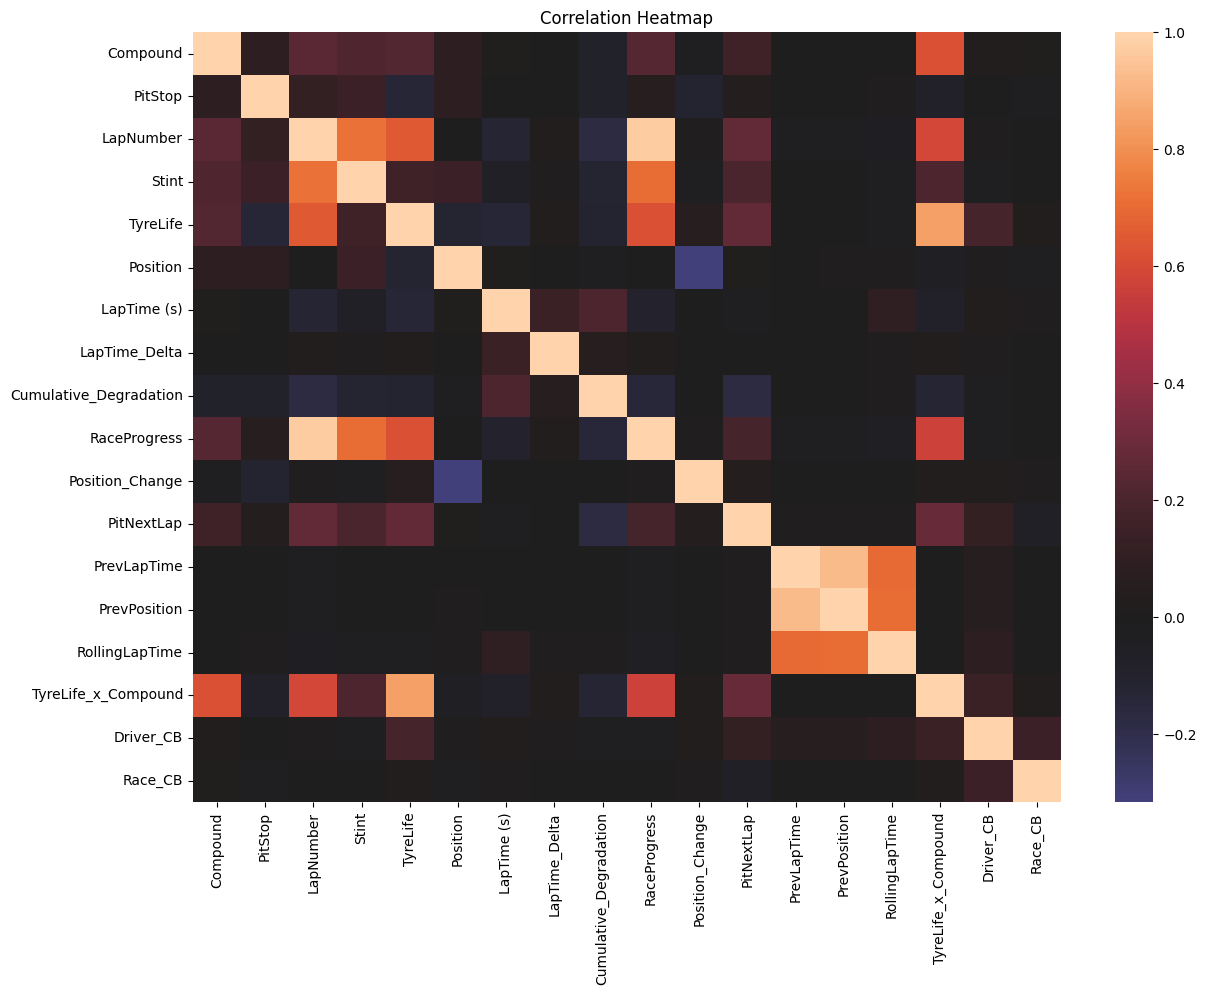

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns only
corr_matrix = train_data.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    #cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
drop_cols = [
    'PitStop',
    'Driver_CB',
    'PrevLapTime',
    'RollingLapTime',
    'PrevPosition'
]

train_data.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [22]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

# Features and target
X = train_data.drop('PitNextLap', axis=1)
y = train_data['PitNextLap']

X_test = test_df.copy()
# Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\n🚀 Fold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # GPU CatBoost Model
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        eval_metric='F1',
        loss_function='Logloss',
        verbose=200,
        random_state=42,

        # GPU settings
        task_type='GPU',
        devices='0'
    )

    # Train
    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Validation predictions
    val_preds = model.predict(X_val)

    oof_preds[val_idx] = val_preds

    # Test predictions
    test_preds += (
        model.predict_proba(X_test)[:, 1] / skf.n_splits
    )

    # Fold score
    score = f1_score(y_val, val_preds)

    print("Fold F1 Score:", score)

# Overall CV score
final_score = f1_score(y, oof_preds)

print("\n🔥 Overall F1 Score:", final_score)


🚀 Fold 1
0:	learn: 0.6633796	test: 0.6644912	best: 0.6644912 (0)	total: 17.7s	remaining: 14h 45m 17s
200:	learn: 0.6842630	test: 0.6804457	best: 0.6804457 (200)	total: 20s	remaining: 4m 37s
400:	learn: 0.7040366	test: 0.7004965	best: 0.7008274 (397)	total: 22.2s	remaining: 2m 23s
600:	learn: 0.7144955	test: 0.7065791	best: 0.7065791 (600)	total: 24.5s	remaining: 1m 37s
800:	learn: 0.7219481	test: 0.7101786	best: 0.7103172 (793)	total: 26.7s	remaining: 1m 13s
1000:	learn: 0.7277824	test: 0.7132398	best: 0.7133192 (981)	total: 28.9s	remaining: 57.8s
1200:	learn: 0.7323160	test: 0.7149452	best: 0.7150838 (1182)	total: 31.2s	remaining: 46.7s
1400:	learn: 0.7369962	test: 0.7160225	best: 0.7160392 (1396)	total: 33.4s	remaining: 38.2s
1600:	learn: 0.7414301	test: 0.7178975	best: 0.7181628 (1580)	total: 35.7s	remaining: 31.2s
1800:	learn: 0.7458342	test: 0.7179517	best: 0.7182035 (1792)	total: 37.9s	remaining: 25.2s
2000:	learn: 0.7493917	test: 0.7185425	best: 0.7185847 (1999)	total: 40.2s	re

                   Feature  Importance
2                    Stint   17.524822
6            LapTime_Delta   17.502382
8             RaceProgress   12.756631
3                 TyreLife   10.528045
5              LapTime (s)    7.267295
1                LapNumber    6.313852
9          Position_Change    6.221392
7   Cumulative_Degradation    6.053058
11                 Race_CB    5.145750
0                 Compound    3.628440
10     TyreLife_x_Compound    3.531637
4                 Position    3.526695


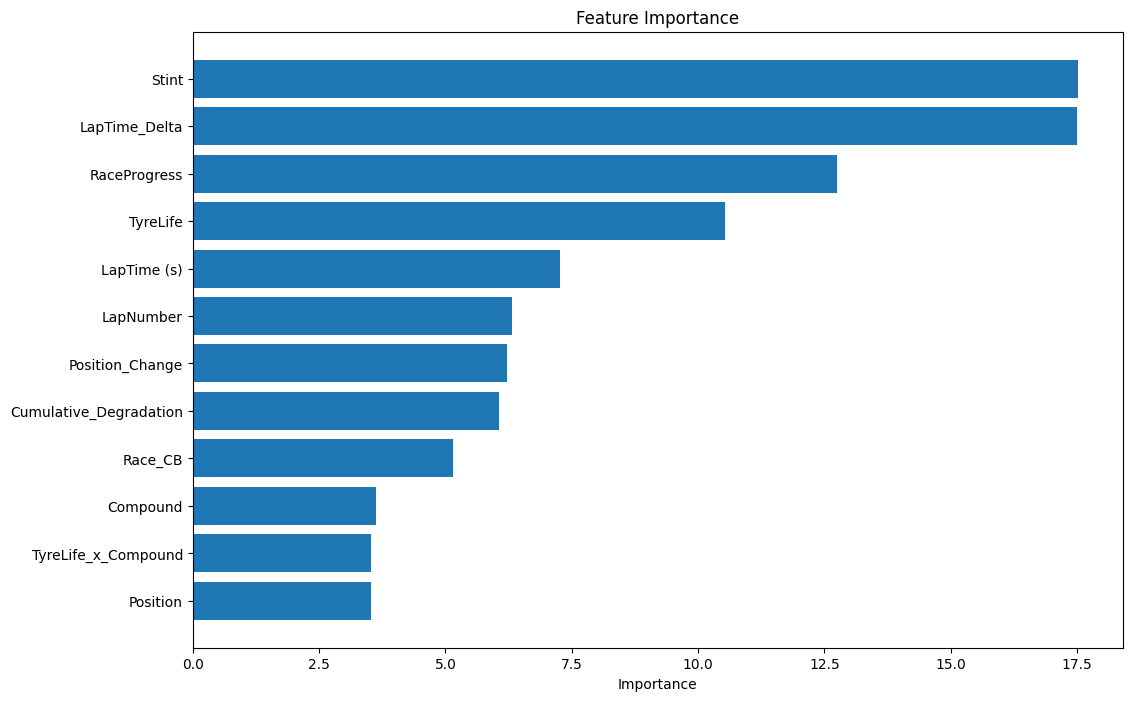

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

In [24]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import numpy as np

In [25]:
X = train_data.drop('PitNextLap', axis=1)
y = train_data['PitNextLap']

X_test = test_df.copy()

#groups = train_data['Race']

gkf = GroupKFold(n_splits=5)

# OOF + Test predictions
oof_preds_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    print(f"\n🚀 Fold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # LightGBM model
    model_lgb = LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=8,
        num_leaves=128,

        subsample=0.8,
        colsample_bytree=0.8,

        min_child_samples=20,

        reg_alpha=0.1,
        reg_lambda=0.1,

        max_bin=63,

        device='gpu',

        random_state=42
)

    # Train
    model_lgb.fit(
        X_train,
        y_train
    )

    # Validation probabilities
    val_preds = model_lgb.predict_proba(X_val)[:, 1]

    oof_preds_lgb[val_idx] = val_preds

    # Test predictions
    test_preds_lgb += (
        model_lgb.predict_proba(X_test)[:, 1]
        / gkf.n_splits
    )

    # Fold score
    score = f1_score(
        y_val,
        (val_preds > 0.5).astype(int)
    )

    print("Fold F1:", score)


🚀 Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69957, number of negative: 281771
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 518
[LightGBM] [Info] Number of data points in the train set: 351728, number of used features: 12
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 64 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 12 dense feature groups (4.03 MB) transferred to GPU in 0.004941 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198895 -> initscore=-1.393214
[LightGBM] [Info] Start training from score -1.393214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [26]:
final_oof = (
    0.6 * oof_preds +
    0.4 * oof_preds_lgb
)

final_test = (
    0.6 * test_preds +
    0.4 * test_preds_lgb
)

In [27]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0
best_score = 0

for thresh in thresholds:

    preds = (final_oof > thresh).astype(int)

    score = f1_score(y, preds)

    if score > best_score:
        best_score = score
        best_thresh = thresh

print("Best Threshold:", best_thresh)
print("Best F1:", best_score)

Best Threshold: 0.24999999999999992
Best F1: 0.7221133486507185


In [28]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"
)


In [29]:
final_preds = (
    final_test > best_thresh
).astype(int)

submission = pd.DataFrame({
    'id': sample_submission['id'],
    'PitNextLap': final_preds
})

submission.to_csv('submission.csv', index=False)

print("Submission file created!")

Submission file created!
